# ENGINE

# Comportamiento de Fidelidad

# 0. Importaciones y Configuración

In [1]:
from astropy.io import fits #Apertura de archivos .fits
import numpy as np #Manipulación de arrays
import matplotlib.pyplot as plt #Visualización de datos
import os #Manipulación de directorios
import sys #Manipulación de rutas

sys.path.append('../../src') #Añadir ruta de src a sys.path

DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data/mock_cubes'
IMGS_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data/imgs'

## 0.1. Parámetros Matplotlib

In [2]:
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 12,
    "figure.figsize": (3.5, 2.625), # 4:3 ratio for single-column
    "savefig.dpi": 600
})

## 0.2. Definición de Funciones

In [3]:
def error_cuadratico_normalizado(valor_observado, valor_referencia, frac_umbral=0):
    """
    Error cuadratico normalizado (NSE): metrica de distancia sin modelo de ruido.

        NSE = sum((obs - ref)^2) / sum(ref^2), sobre la region de emision.

    La normalizacion es GLOBAL (sum(ref^2)) en vez de pixel a pixel, asi los
    pixeles debiles no inflan el resultado. Adimensional: 0 = identico a la
    referencia, y comparable entre mapas y metodos.

    - frac_umbral : fraccion del peak de la REFERENCIA para definir la region
      de emision (la misma mascara para todos los mapas).
    """
    mask = valor_referencia > frac_umbral * np.max(valor_referencia)
    obs, ref = valor_observado[mask], valor_referencia[mask]
    return np.sum((np.abs(obs) - np.abs(ref)) ** 2) / np.sum(ref ** 2)

def regresion_obs_ref(valor_observado, valor_referencia, incluir_cero=True):
    """
    Compara obs vs ref mediante regresion lineal: obs = a * ref + b.

    Separa tres efectos que el chi^2 mezcla o ignora:
      pendiente a : sesgo de flujo / ganancia (1.0 = flujo recuperado; a<1 = perdida)
      intercepto b: flujo espurio / offset sistematico (idealmente 0)
      r2          : fraccion de varianza explicada (fidelidad punto a punto)
      dispersion  : RMSE del residuo obs - (a*ref + b)

    incluir_cero=True usa todos los pixeles, de modo que los pixeles con ref=0
    hacen que el intercepto capture el flujo espurio fuera del soporte real.
    incluir_cero=False ajusta solo donde ref > 0 (comparable al chi^2 actual).
    """
    obs = np.asarray(valor_observado, dtype=float)
    ref = np.asarray(valor_referencia, dtype=float)

    if not incluir_cero:
        mask = ref > 0
        obs, ref = obs[mask], ref[mask]

    a, b = np.polyfit(ref, obs, 1)
    modelo = a * ref + b
    ss_res = np.sum((obs - modelo) ** 2)
    ss_tot = np.sum((obs - np.mean(obs)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    dispersion = np.sqrt(np.mean((obs - modelo) ** 2))

    return {'pendiente': a, 'intercepto': b, 'r2': r2, 'dispersion': dispersion}


def recuperacion_por_brillo(valor_observado, valor_referencia, n_bins=12, ref_min=None):
    """
    Fraccion de flujo recuperado en funcion del brillo de la referencia.

    Agrupa los pixeles en bins log-espaciados segun ref y, en cada bin,
    calcula mediana(obs) / mediana(ref). Asi se ve si la emision DEBIL
    (que la pendiente global ignora por el rango dinamico) se recupera o no.

    ref_min: piso de brillo. Solo se binean pixeles con ref >= ref_min, para
             evitar el blow-up del cociente en bins donde ref -> 0 (alas del
             beam / no señal real). Si None, usa el minimo positivo de ref.

    Devuelve (centros_bin, recuperacion); recuperacion ~ 1 = flujo recuperado.
    """
    obs = np.asarray(valor_observado, dtype=float)
    ref = np.asarray(valor_referencia, dtype=float)

    mask = ref > 0
    if ref_min is not None:
        mask &= ref >= ref_min
    obs, ref = obs[mask], ref[mask]

    if ref.size == 0:
        return np.array([]), np.array([])

    bordes = np.logspace(np.log10(ref.min()), np.log10(ref.max()), n_bins + 1)
    idx = np.digitize(ref, bordes)

    centros, recuperacion = [], []
    for k in range(1, n_bins + 1):
        sel = idx == k
        if np.count_nonzero(sel) == 0:
            continue
        ref_med = np.median(ref[sel])
        if ref_med == 0:
            continue
        centros.append(ref_med)
        recuperacion.append(np.median(obs[sel]) / ref_med)
    return np.array(centros), np.array(recuperacion)


def cargar_momentos_log(subdir, momento_idx, umbral_inicial, umbral_step, cubo, cube_dir):
    hdu = fits.open(os.path.join(DATA_DIR, cube_dir, f'{cubo}.fits'))
    flux_max = np.nanmax(np.squeeze(hdu[0].data))
    cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    momentos = []
    for k in range(cantidad):
        umbral = umbral_inicial * (umbral_step ** k)
        ruta = os.path.join(
            DATA_DIR, CUBE_DIR, subdir,
            f'iter_flux_{umbral:.3e}',
            f'iter_flux_{umbral:.3e}_moment{momento_idx}.fits',
        )
        hdu = fits.open(ruta)
        momento = np.squeeze(hdu[0].data)
        momentos.append(np.nan_to_num(momento).flatten())
    return momentos

def flux_max(cubo, cube_dir):
    hdu = fits.open(os.path.join(DATA_DIR, cube_dir, f'{cubo}.fits'))
    flux_max = np.nanmax(np.squeeze(hdu[0].data))
    return flux_max

def umbrales_log(flux_max, umbral_inicial, umbral_step):
    cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    return umbral_inicial * umbral_step ** np.arange(cantidad)

## 0.3. Variables Cubo a analizar

In [4]:
CUBE_DIR = 'perpendicular_138_rotx30y50_AC2_N100'

AC = 'AC2'

IterativeMin = 1.0e-7
IterativeStep = 1.5

cantidad_de_cubos = 6

# 1. Momentos de Referencia

In [5]:
moments_ref = {}
for i in range(3):
    hdu = fits.open(os.path.join(
        DATA_DIR,
        CUBE_DIR,
        'moments_ref',
        f'notnoisy_moment{i}_{AC}.fits'
    ))
    moment = np.squeeze(hdu[0].data)
    moment_ref_flat = np.clip(np.nan_to_num(moment).flatten(),0,None)
    moments_ref[i] = moment_ref_flat

In [6]:
umbrales = {}
for i in range(cantidad_de_cubos):
    if i == 0:
        flux_max_val = flux_max(
            f'{CUBE_DIR}_noisy_sub',
            CUBE_DIR
        )
        umbral = umbrales_log(
            flux_max_val, IterativeMin, IterativeStep
        )
        umbrales['noisy'] = umbral

    else:
        flux_max_val = flux_max(
            f'{CUBE_DIR}_noisy_sub_wavelets_iterative_soft_{i}',
            CUBE_DIR
        )
        umbral = umbrales_log(
            flux_max_val, IterativeMin, IterativeStep
        )
        umbrales[f'soft_{i}'] = umbral

# 3. Momentos-0

## 3.1. Apertura

In [7]:
moments = {}
for i in range(cantidad_de_cubos):
    if i == 0:
        moment = cargar_momentos_log(
            'moments_noisy',
            0, IterativeMin, IterativeStep,
            f'{CUBE_DIR}_noisy_sub', CUBE_DIR
        )
        moments['noisy'] = moment
    else:
        moment = cargar_momentos_log(
            f'moments_soft_{i}',
            0, IterativeMin, IterativeStep,
            f'{CUBE_DIR}_noisy_sub_wavelets_iterative_soft_{i}',
            CUBE_DIR
        )
        moments[f'soft_{i}'] = moment

## 3.2. Error Cuadrático Normalizado (NSE)

In [8]:
nse_valores = {}
for i in range(cantidad_de_cubos):
    if i == 0:
        nse_list = []
        for m in moments['noisy']:
            nse = error_cuadratico_normalizado(m, moments_ref[0])
            nse_list.append(nse)
        nse_valores['noisy'] = nse_list
    else:
        nse_list = []
        for m in moments[f'soft_{i}']:
            nse = error_cuadratico_normalizado(m, moments_ref[0])
            nse_list.append(nse)
        nse_valores[f'soft_{i}'] = nse_list

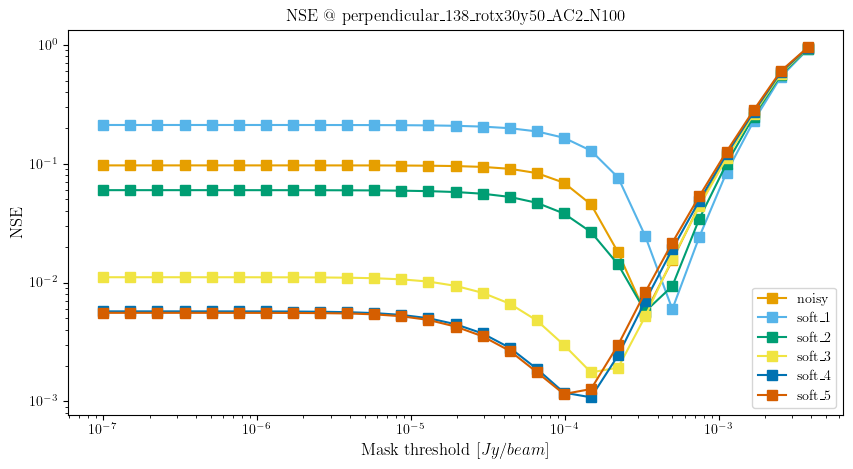

In [9]:
plt.figure(figsize=(10, 5))
for name, nse in nse_valores.items():
    plt.errorbar(
        umbrales[name],
        nse,
        ms=7,
        label=f'{name}',
        marker='s'
    )
plt.xlabel('Mask threshold [$Jy/beam$]')
plt.ylabel('NSE')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.yscale('log')
plt.xscale('log')
plt.title(f'NSE @ {CUBE_DIR}')
plt.legend()
plt.savefig(os.path.join(IMGS_DIR, f'nse_{CUBE_DIR}.png'))

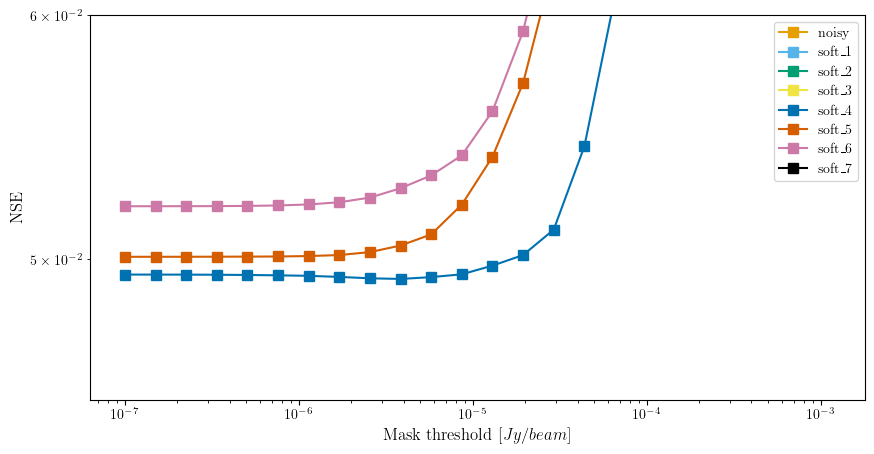

In [76]:
plt.figure(figsize=(10, 5))
for name, nse in nse_valores.items():
    plt.errorbar(
        umbrales[name],
        nse,
        ms=7,
        label=f'{name}',
        marker='s'
    )
plt.xlabel('Mask threshold [$Jy/beam$]')
plt.ylabel('NSE')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.yscale('log')
plt.xscale('log')
plt.ylim(4.5e-2,6e-2)
plt.legend()
plt.savefig(os.path.join(IMGS_DIR, f'nse_{CUBE_DIR}_closeup.png'))

## 3.3. Regresión

In [16]:
# moments['soft_N'] es una LISTA de mapas (uno por umbral de mascara),
# asi que la regresion se aplica mapa por mapa recorriendo los umbrales.
momentos_por_soft = {
    #'Soft 7': (umbrales['soft_7'], moments['soft_7']),
    #'Soft 6': (umbrales['soft_6'], moments['soft_6']),
    'Soft 5': (umbrales['soft_5'], moments['soft_5']),
    'Soft 4': (umbrales['soft_4'], moments['soft_4']),
    'Soft 3': (umbrales['soft_3'], moments['soft_3']),
    'Soft 2': (umbrales['soft_2'], moments['soft_2']),
    'Soft 1': (umbrales['soft_1'], moments['soft_1']),
    'Noisy':  (umbrales['noisy'],  moments['noisy']),
}

def _curvas_regresion(incluir_cero):
    salida = {}
    for nombre, (umbrales_curva, momentos) in momentos_por_soft.items():
        diags = [regresion_obs_ref(m, moments_ref[0], incluir_cero=incluir_cero)
                 for m in momentos]
        salida[nombre] = {
            'umbrales':   umbrales_curva,
            'pendiente':  [d['pendiente']  for d in diags],
            'intercepto': [d['intercepto'] for d in diags],
            'r2':         [d['r2']         for d in diags],
            'dispersion': [d['dispersion'] for d in diags],
        }
    return salida

# regresion_por_soft[True]  -> ajuste con todos los pixeles (intercepto = flujo espurio)
# regresion_por_soft[False] -> ajuste solo donde ref > 0 (comparable al chi^2)
regresion_por_soft = {
    True:  _curvas_regresion(incluir_cero=True),
    False: _curvas_regresion(incluir_cero=False),
}


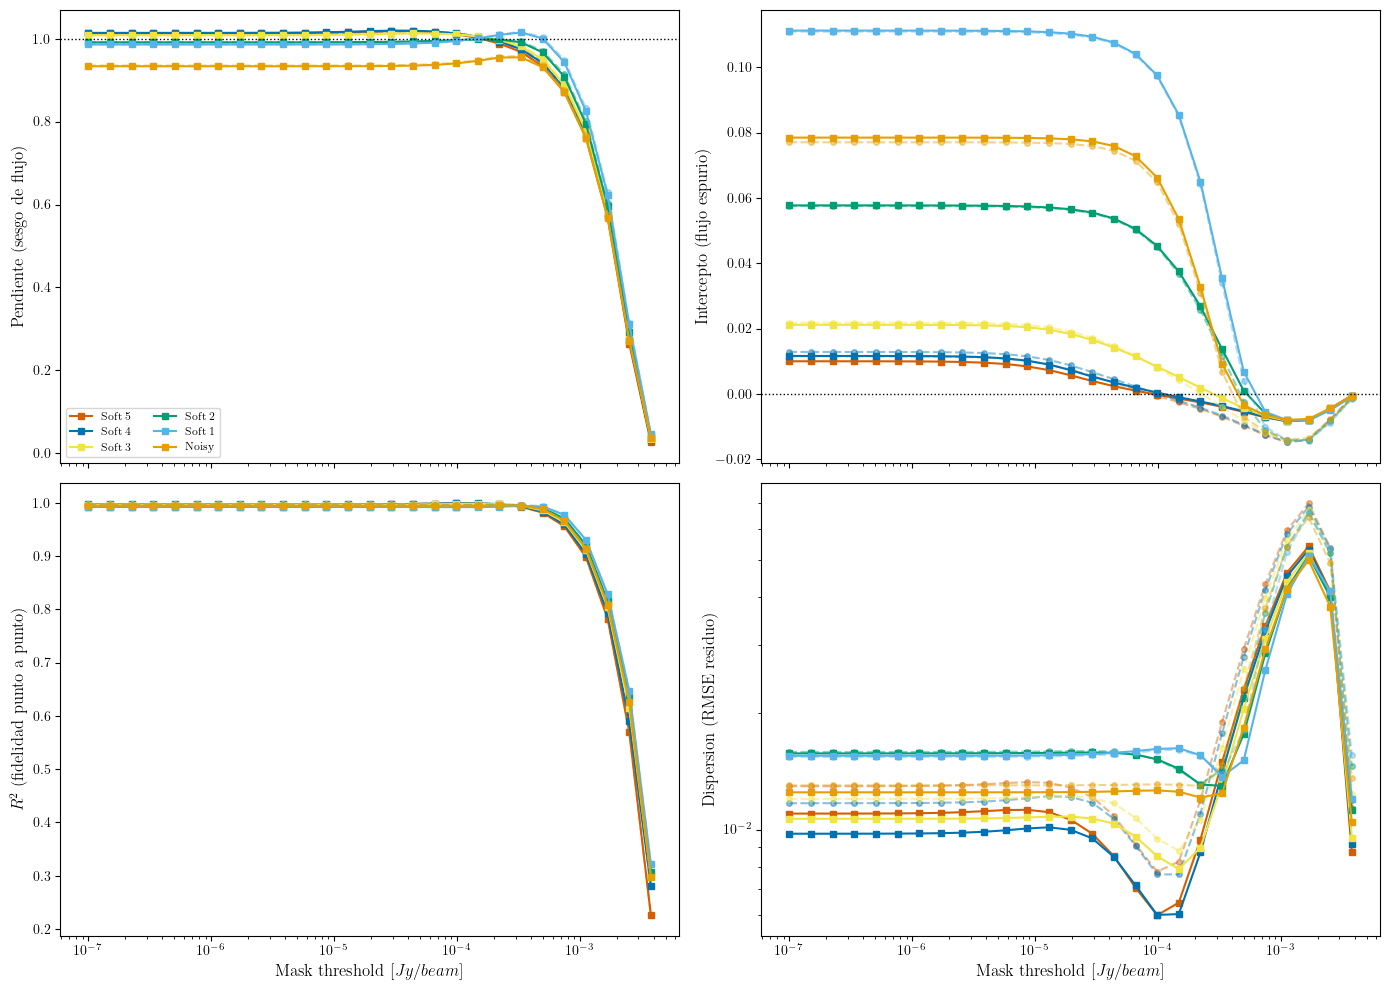

In [17]:
diagnosticos = ['pendiente', 'intercepto', 'r2', 'dispersion']
titulos = {
    'pendiente':  'Pendiente (sesgo de flujo)',
    'intercepto': 'Intercepto (flujo espurio)',
    'r2':         '$R^2$ (fidelidad punto a punto)',
    'dispersion': 'Dispersion (RMSE residuo)',
}

# Mismos colores que el grafico de NSE: 'noisy'->C0, 'soft_i'->Ci
ciclo_colores = plt.rcParams['axes.prop_cycle'].by_key()['color']
def _color_nse(nombre):
    clave = nombre.lower().replace(' ', '_')  # 'Soft 5'->'soft_5', 'Noisy'->'noisy'
    idx = 0 if clave == 'noisy' else int(clave.split('_')[1])
    return ciclo_colores[idx % len(ciclo_colores)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
for ax, diag in zip(axes.flat, diagnosticos):
    for nombre in momentos_por_soft:
        color = _color_nse(nombre)
        c_con = regresion_por_soft[True][nombre]   # solido + cuadrado
        c_sin = regresion_por_soft[False][nombre]  # discontinuo + circulo
        linea, = ax.plot(c_con['umbrales'], c_con[diag], marker='s', ms=5, label=nombre, color=color)
        ax.plot(c_sin['umbrales'], c_sin[diag], marker='o', ms=4, ls='--',
                color=color, alpha=0.45)
    ax.set_ylabel(titulos[diag])
    ax.set_xscale('log')
    if diag == 'pendiente':
        ax.axhline(1.0, ls=':', color='k', lw=1)
    if diag == 'intercepto':
        ax.axhline(0.0, ls=':', color='k', lw=1)
    if diag == 'dispersion':
        ax.set_yscale('log')

for ax in axes[1]:
    ax.set_xlabel('Mask threshold [$Jy/beam$]')
axes[0, 0].legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.savefig(os.path.join(IMGS_DIR, f'regresion_{CUBE_DIR}.png'))

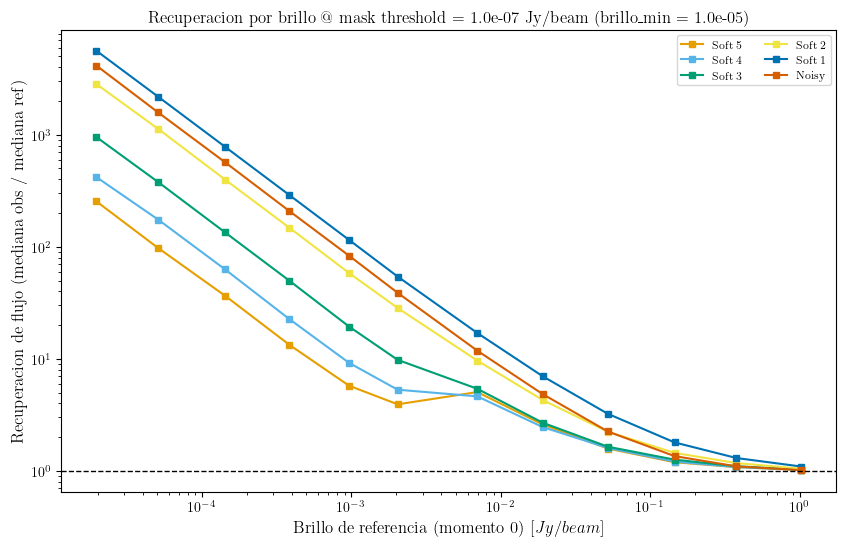

In [19]:
# Recuperacion de flujo vs brillo, para ver si la emision DEBIL sobrevive
# (la pendiente global la dominan los pixeles brillantes).
# idx_umbral=0 -> mask threshold mas bajo (1e-7): zona de plateau y comparable
# entre niveles, porque umbrales_log arranca siempre en IterativeMin.
#
# brillo_min: piso de brillo para evitar el blow-up del cociente donde ref->0
# (alas del beam, no señal real). Sube/baja este valor para acotar al rango
# de emision genuina.
idx_umbral = 0
brillo_min = 1e-5  # Jy/beam

plt.figure(figsize=(10, 6))
for nombre, (umbrales_curva, momentos) in momentos_por_soft.items():
    centros, recup = recuperacion_por_brillo(
        momentos[idx_umbral], moments_ref[0], n_bins=12, ref_min=brillo_min)
    plt.plot(centros, recup, marker='s', ms=5, label=nombre)
plt.axhline(1.0, ls='--', color='k', lw=1)  # recuperacion perfecta
plt.xlabel('Brillo de referencia (momento 0) [$Jy/beam$]')
plt.ylabel('Recuperacion de flujo (mediana obs / mediana ref)')
plt.xscale('log')
plt.yscale('log')  # los puntos con cociente <= 0 se omiten automaticamente
plt.title(f'Recuperacion por brillo @ mask threshold = {umbrales["soft_5"][idx_umbral]:.1e} Jy/beam'
          f'  (brillo_min = {brillo_min:.1e})')
plt.legend(ncol=2, fontsize=8)
plt.savefig(os.path.join(IMGS_DIR, f'recuperacion_por_brillo_{CUBE_DIR}.png'))

# 4. Momentos-1

## 4.1. Apertura

In [56]:
moments = {}
for i in range(cantidad_de_cubos):
    if i == 0:
        moment = cargar_momentos_log(
            'moments_noisy',
            1, IterativeMin, IterativeStep,
            f'{CUBE_DIR}_noisy_sub', CUBE_DIR
        )
        moments['noisy'] = moment
    else:
        moment = cargar_momentos_log(
            f'moments_soft_{i}',
            1, IterativeMin, IterativeStep,
            f'{CUBE_DIR}_noisy_sub_wavelets_iterative_soft_{i}',
            CUBE_DIR
        )
        moments[f'soft_{i}'] = moment

## 4.2. Error Cuadrático Normalizado (NSE)

In [57]:
nse_valores = {}
for i in range(cantidad_de_cubos):
    if i == 0:
        nse_list = []
        for m in moments['noisy']:
            nse = error_cuadratico_normalizado(m, moments_ref[1])
            nse_list.append(nse)
        nse_valores['noisy'] = nse_list
    else:
        nse_list = []
        for m in moments[f'soft_{i}']:
            nse = error_cuadratico_normalizado(m, moments_ref[1])
            nse_list.append(nse)
        nse_valores[f'soft_{i}'] = nse_list

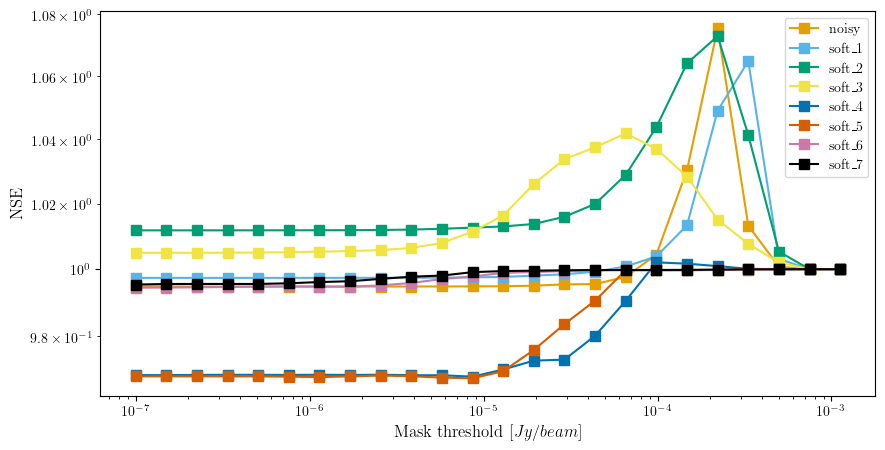

In [58]:
plt.figure(figsize=(10, 5))
for name, nse in nse_valores.items():
    plt.errorbar(
        umbrales[name],
        nse,
        ms=7,
        label=f'{name}',
        marker='s'
    )
plt.xlabel('Mask threshold [$Jy/beam$]')
plt.ylabel('NSE')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.savefig(os.path.join(IMGS_DIR, 'nse.png'))

# 5. Momentos-2

## 5.1. Apertura

In [43]:
moments = {}
for i in range(cantidad_de_cubos):
    if i == 0:
        moment = cargar_momentos_log(
            'moments_noisy',
            2, IterativeMin, IterativeStep,
            f'{CUBE_DIR}_noisy_sub', CUBE_DIR
        )
        moments['noisy'] = moment
    else:
        moment = cargar_momentos_log(
            f'moments_soft_{i}',
            2, IterativeMin, IterativeStep,
            f'{CUBE_DIR}_noisy_sub_wavelets_iterative_soft_{i}',
            CUBE_DIR
        )
        moments[f'soft_{i}'] = moment

## 5.2. Error Cuadrático Normalizado (NSE)

In [44]:
nse_valores = {}
for i in range(cantidad_de_cubos):
    if i == 0:
        nse_list = []
        for m in moments['noisy']:
            nse = error_cuadratico_normalizado(m, moments_ref[2])
            nse_list.append(nse)
        nse_valores['noisy'] = nse_list
    else:
        nse_list = []
        for m in moments[f'soft_{i}']:
            nse = error_cuadratico_normalizado(m, moments_ref[2])
            nse_list.append(nse)
        nse_valores[f'soft_{i}'] = nse_list

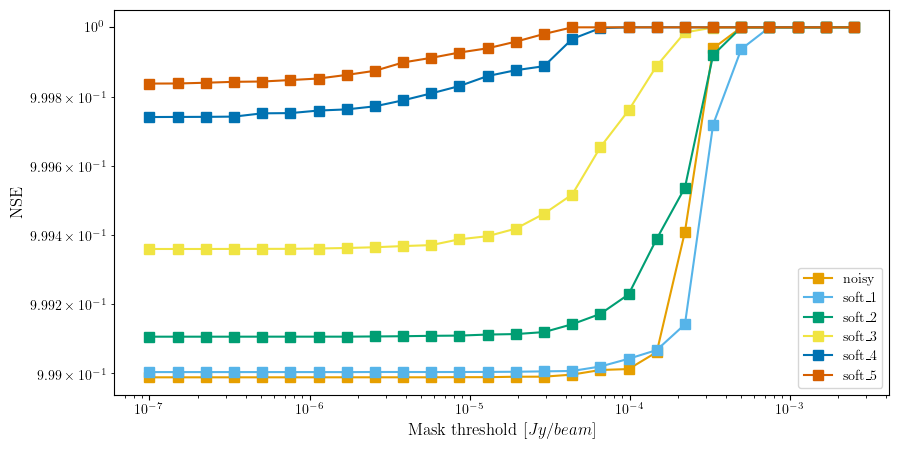

In [45]:
plt.figure(figsize=(10, 5))
for name, nse in nse_valores.items():
    plt.errorbar(
        umbrales[name],
        nse,
        ms=7,
        label=f'{name}',
        marker='s'
    )
plt.xlabel('Mask threshold [$Jy/beam$]')
plt.ylabel('NSE')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.savefig(os.path.join(IMGS_DIR, 'nse.png'))